# Price Imitator — Exploratory Data Analysis

This notebook reads in two parts:

1. **Part 1 — The Data Story.** 
2. **Part 2 — Methodology & Data Quality.** Is the data trustworthy, and *why* was each modelling decision taken? Each check ends with a `➡ Decision` callout linking it to the imitator/initializer models.

## Setup

Load the weekly extract and build the option-week feature table once — reusing `PriceFeatureBuilder` so the story below uses the very features the models consume.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.mekong_delta_price_features import PriceFeatureBuilder

CSV = REPO_ROOT / "data" / "raw" / "Mekong_Delta_Multiple_campsites_datasets_capacity_over_200_anonymised_final.csv"
df = pd.read_csv(CSV, low_memory=False, na_values=["null"])
df["WeekStartDate"] = pd.to_datetime(df["WeekStartDate"])
df["Year"] = df["WeekStartDate"].dt.year
df = df[df["Capacity"] > 0].copy()

# Build the option-week feature table once (same layer the models use).
builder = PriceFeatureBuilder()
option_week = builder.build_option_week_table(df)
option_week = builder.add_initial_prices(df, option_week)
option_week = builder.add_demand_features(df, option_week)

print(f"raw rows: {len(df):,} | option-weeks: {len(option_week):,}")
print(f"arrival years: {sorted(df['Year'].unique())}")

raw rows: 1,214,072 | option-weeks: 3,842
arrival years: [np.int32(2024), np.int32(2025), np.int32(2026)]


In [2]:
# What does the data look like?
df.head()

,ReservableOptionId,ReservableOptionMarketGroupId,BrandGroupCode,CampsiteCode,AccoTypeRangeCode,MarketGroupCode,WeekBeforeArrival,WeekStartDate,ArrivalMonth,SpecialPeriodCode,...,AverageDiscPriceForWeekBeforeArrivalLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,CumulativeHistoricalBookedNights,CumulativeHistoricalBookedNightsLastYear,TotalBookedNights,CapacityLastYear,Capacity,SoldOutWeekBeforeArrival,Year
0,82307070,858803906,BrandGroup1,Campsite021,WV | Chill+,CN,78,2025-07-19,7,NaN,...,0.0,NaN,0,0,0,172,266.0,266,NaN,2025
1,82307070,858803906,BrandGroup1,Campsite021,WV | Chill+,CN,77,2025-07-19,7,NaN,...,0.0,NaN,0,0,0,172,266.0,266,NaN,2025
2,82307070,858803906,BrandGroup1,Campsite021,WV | Chill+,CN,76,2025-07-19,7,NaN,...,0.0,NaN,0,0,0,172,266.0,266,NaN,2025
3,82307070,858803906,BrandGroup1,Campsite021,WV | Chill+,CN,75,2025-07-19,7,NaN,...,0.0,NaN,0,0,0,172,266.0,266,NaN,2025
4,82307070,858803906,BrandGroup1,Campsite021,WV | Chill+,CN,74,2025-07-19,7,NaN,...,0.0,NaN,0,0,0,172,266.0,266,NaN,2025


In [3]:
# Which columns are available?
df.columns

Index(['ReservableOptionId', 'ReservableOptionMarketGroupId', 'BrandGroupCode',
       'CampsiteCode', 'AccoTypeRangeCode', 'MarketGroupCode',
       'WeekBeforeArrival', 'WeekStartDate', 'ArrivalMonth',
       'SpecialPeriodCode', 'SeasonalCluster', 'CampsiteCountry',
       'CampsiteRegion', 'CampsiteType', 'AccommodationType',
       'AccommodationRange', 'Airco', 'Bedrooms', 'DeckingType', 'HotTub',
       'Tropical', 'Roof', 'Kitchen', 'DeckingExtras', 'Bathrooms', 'Sleeps',
       'TV', 'AverageDiscPriceForWeekBeforeArrival',
       'AverageDiscPriceForWeekBeforeArrivalLastYear',
       'HistoricalBookedNights', 'HistoricalBookedNightsLastYear',
       'CumulativeHistoricalBookedNights',
       'CumulativeHistoricalBookedNightsLastYear', 'TotalBookedNights',
       'CapacityLastYear', 'Capacity', 'SoldOutWeekBeforeArrival', 'Year'],
      dtype='object')

# Part 1 — The Data Story

## 1. Price distribution & skew

Opening prices are heavily **right-skewed**: most options are cheap, a long tail is expensive. `log1p` pulls that tail in and makes the distribution roughly symmetric.

> ➡ **Decision:** the models fit on `log1p(price)` and back-transform with `expm1` — this stabilises variance and turns the error into a ~percentage error (better MAPE). The price floor (no €0 openings) is why `InitialPrice ≤ 0` rows are dropped before training.

count    3353.00
mean      114.75
std        85.37
min        28.25
25%        50.50
50%        73.66
75%       169.00
max       535.00


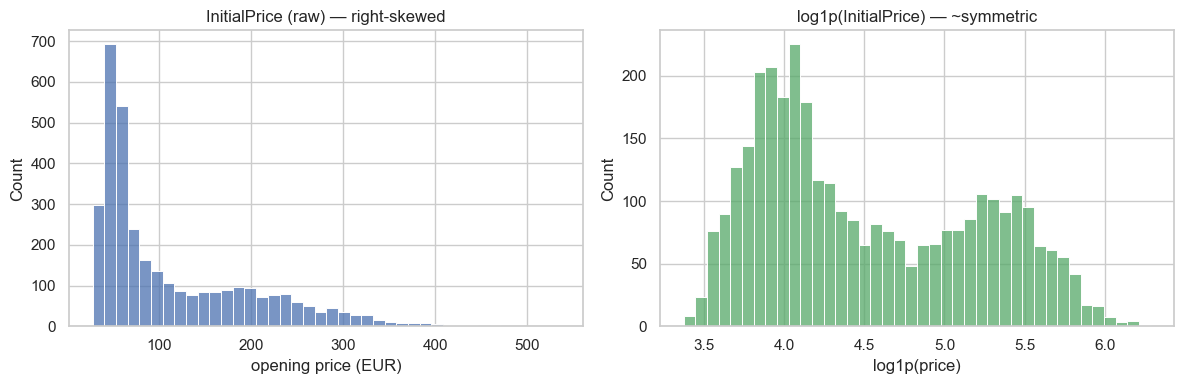

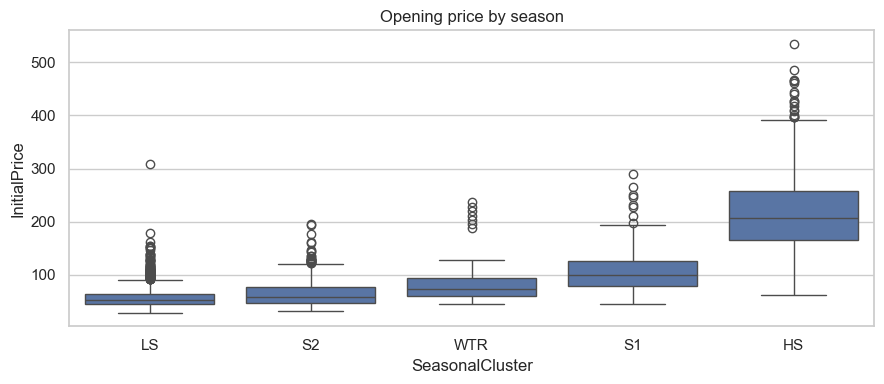

In [4]:
price = option_week["InitialPrice"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(price, bins=40, ax=axes[0], color="#4c72b0")
axes[0].set(title="InitialPrice (raw) — right-skewed", xlabel="opening price (EUR)")
sns.histplot(np.log1p(price), bins=40, ax=axes[1], color="#55a868")
axes[1].set(title="log1p(InitialPrice) — ~symmetric", xlabel="log1p(price)")
fig.tight_layout()

order = option_week.groupby("SeasonalCluster")["InitialPrice"].median().sort_values().index
plt.figure(figsize=(9, 4))
sns.boxplot(data=option_week, x="SeasonalCluster", y="InitialPrice", order=order)
plt.title("Opening price by season"); plt.tight_layout()
print(price.describe().round(2).to_string())

## 2. The booking curve

The heart of revenue management: as the arrival date approaches (weeks-before-arrival counts **down**), occupancy builds and the average price drifts. The shape differs by season.

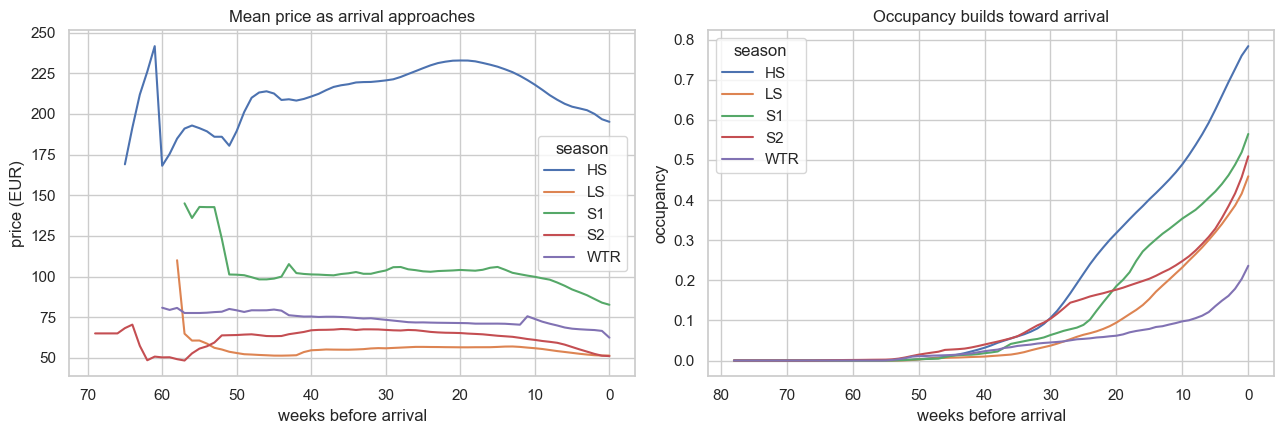

In [5]:
# Collapse the 4 market groups to one row per (option, horizon).
curve = (
    df.groupby(["ReservableOptionId", "WeekBeforeArrival"], as_index=False)
    .agg(price=("AverageDiscPriceForWeekBeforeArrival", "mean"),
         booked=("CumulativeHistoricalBookedNights", "sum"),
         capacity=("Capacity", "first"),
         season=("SeasonalCluster", "first"))
)
curve["price"] = curve["price"].where(curve["price"] > 0)
curve["occupancy"] = (curve["booked"] / curve["capacity"]).clip(0, 1)

agg = (curve.groupby(["season", "WeekBeforeArrival"])
       .agg(price=("price", "mean"), occupancy=("occupancy", "mean")).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=agg, x="WeekBeforeArrival", y="price", hue="season", ax=axes[0])
axes[0].invert_xaxis()
axes[0].set(title="Mean price as arrival approaches", xlabel="weeks before arrival", ylabel="price (EUR)")
sns.lineplot(data=agg, x="WeekBeforeArrival", y="occupancy", hue="season", ax=axes[1])
axes[1].invert_xaxis()
axes[1].set(title="Occupancy builds toward arrival", xlabel="weeks before arrival", ylabel="occupancy")
fig.tight_layout()

## 3. Price decline from the opening price

Two deeper views of the booking curve, focused on **how the price moves relative to its opening level** as a week fills.

- **Decline path (per year × season).** Average % drop from `InitialPrice` (red, left axis) vs average occupancy (blue dotted, right axis) as arrival approaches.
- **Cuts vs raises before a trigger.** Per season we count price **cuts** (bars rising from the floor) and **raises** (bars hanging from the roof) before a trigger fires, under two triggers: (a) before the week reaches its **occupancy threshold**, and (b) in the **early / pre-demand window** (`WeekBeforeArrival > cutoff`, since demand only lifts off ~WBA 30 for HS/S2 and ~20 for LS). Both are adjustable.

> ➡ **Insight:** prices often step **up** in the quiet early window, then **ladder down** as arrival nears and demand decides the outcome — exactly the dynamic the **initializer** (`TargetPrice` at X% occupancy) tries to capture.

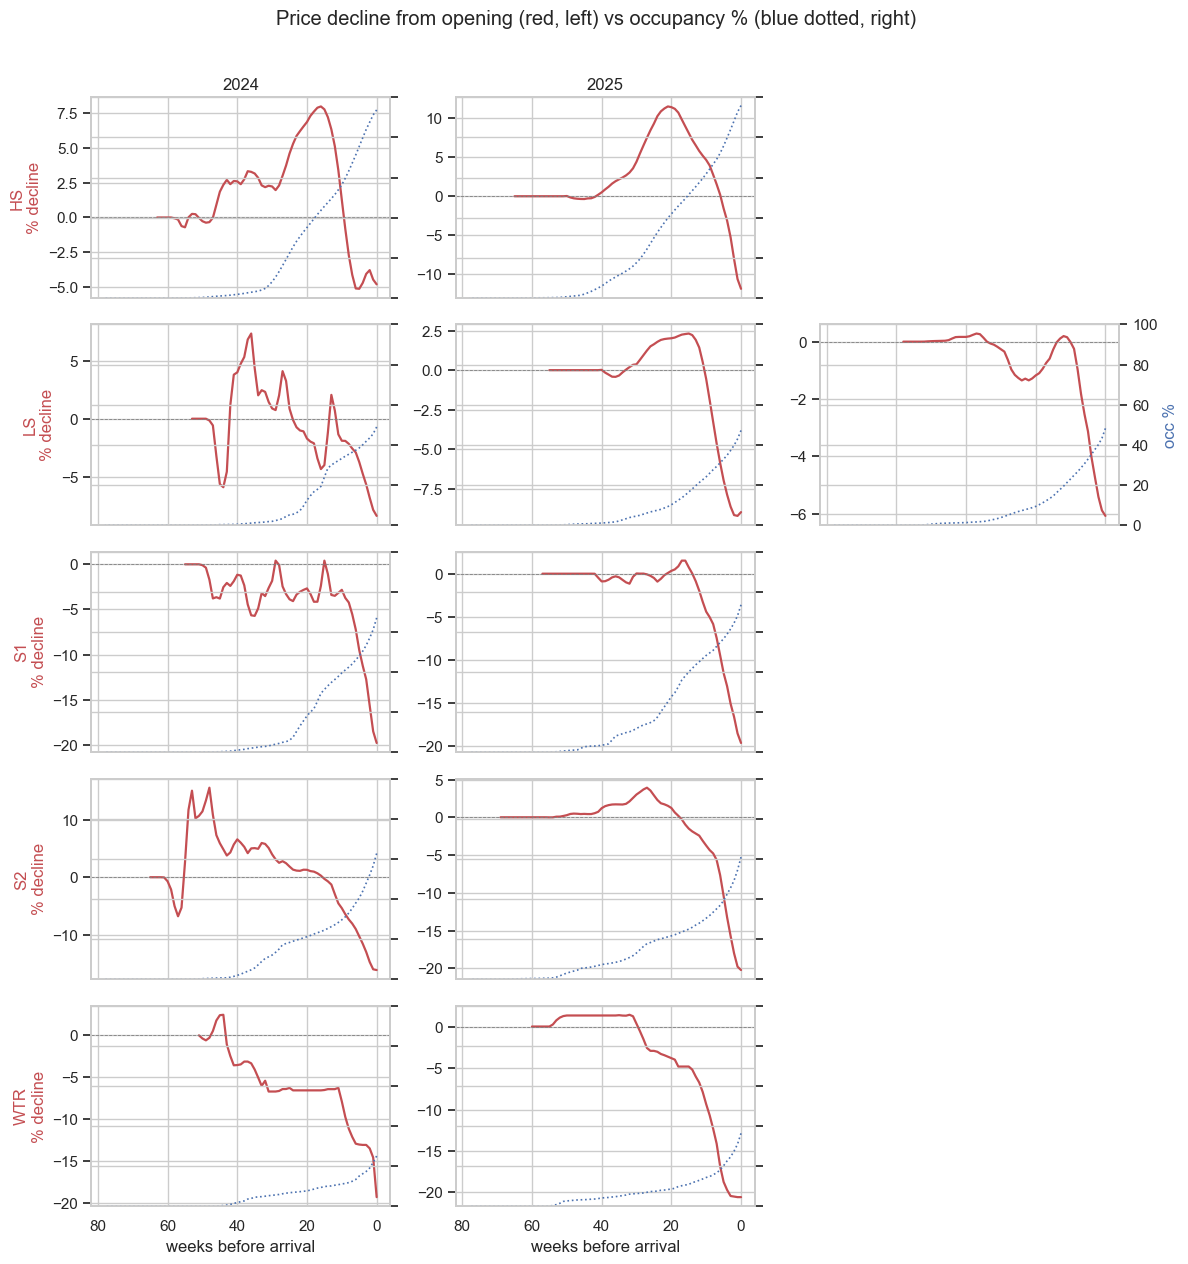

In [6]:
# V1 — average % price decline from the opening price (red, left) with average
# occupancy (blue dotted, right), one panel per year x season.
# Reuse `curve` (option x horizon, from the booking-curve cell) + the option's Year/InitialPrice.
dec = curve.merge(
    option_week[["ReservableOptionId", "Year", "InitialPrice"]],
    on="ReservableOptionId", how="left",
)
dec = dec[dec["InitialPrice"] > 0].copy()
dec["decline_pct"] = (dec["price"] / dec["InitialPrice"] - 1) * 100   # 0 at opening, <0 toward arrival

grid = (dec.groupby(["season", "Year", "WeekBeforeArrival"])
        .agg(decline=("decline_pct", "mean"), occ=("occupancy", "mean")).reset_index())

seasons = ["HS", "LS", "S1", "S2", "WTR"]
years = sorted(int(y) for y in dec["Year"].dropna().unique())
fig, axes = plt.subplots(len(seasons), len(years), sharex=True,
                         figsize=(4 * len(years), 2.5 * len(seasons)))
for r, s in enumerate(seasons):
    for c, y in enumerate(years):
        ax = axes[r, c]
        sub = grid[(grid["season"] == s) & (grid["Year"] == y)].sort_values("WeekBeforeArrival")
        if sub.empty:
            ax.axis("off")
            continue
        ax.plot(sub["WeekBeforeArrival"], sub["decline"], color="#c44e52", lw=1.6)
        ax.axhline(0, color="grey", lw=0.6, ls="--")
        ax2 = ax.twinx()
        ax2.plot(sub["WeekBeforeArrival"], sub["occ"] * 100, color="#4c72b0", lw=1.2, ls=":")
        ax2.set_ylim(0, 100)
        ax.invert_xaxis()
        if c == 0:
            ax.set_ylabel(f"{s}\n% decline", color="#c44e52")
        if c == len(years) - 1:
            ax2.set_ylabel("occ %", color="#4c72b0")
        else:
            ax2.set_yticklabels([])
        if r == 0:
            ax.set_title(str(y))
        if r == len(seasons) - 1:
            ax.set_xlabel("weeks before arrival")
fig.suptitle("Price decline from opening (red, left) vs occupancy % (blue dotted, right)", y=1.01)
fig.tight_layout()

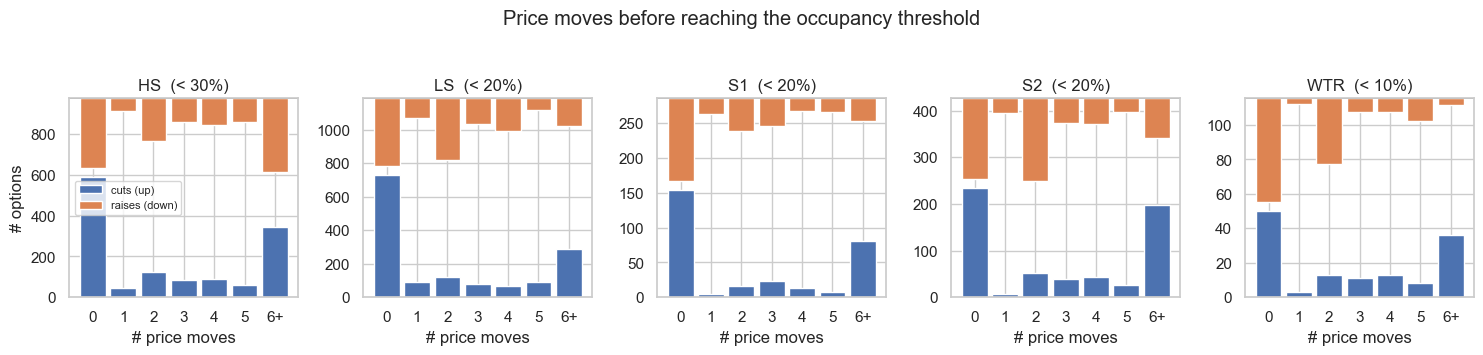

interactive(children=(FloatSlider(value=0.0, description='occ %', max=0.6, step=0.05), Output()), _dom_classes…

<function __main__.show_occ(global_pct)>

In [7]:
# V2 -- price CUTS (rise from the floor) and RAISES (hang from the roof) before a trigger.
# Helpers below are shared with the WBA-window version in the next cell.
_season_of = curve.drop_duplicates("ReservableOptionId").set_index("ReservableOptionId")["season"]

def count_moves(opt, mode, params):
    """(#cuts, #raises) among priced horizons before the trigger fires.

    mode="occ": count while cumulative occupancy < params[season] (a fraction).
    mode="wba": count while WeekBeforeArrival > params[season] (early pre-demand window).
    """
    o = opt.sort_values("WeekBeforeArrival", ascending=False)   # earliest -> latest
    thr = params.get(o["season"].iloc[0])
    cuts = raises = 0
    last = None
    for wba, price, occ in zip(o["WeekBeforeArrival"].to_numpy(),
                               o["price"].to_numpy(), o["occupancy"].to_numpy()):
        if mode == "occ":
            if thr is not None and occ >= thr:
                break
        else:  # "wba": stop once we reach the cutoff lead time
            if thr is not None and wba <= thr:
                break
        if not np.isnan(price):
            if last is not None:
                if price < last - 1e-9:
                    cuts += 1
                elif price > last + 1e-9:
                    raises += 1
            last = price
    return pd.Series({"cuts": cuts, "raises": raises})

def move_counts(mode, params):
    cdf = curve.groupby("ReservableOptionId").apply(
        lambda o: count_moves(o, mode, params), include_groups=False)
    cdf["season"] = _season_of
    return cdf.dropna(subset=["season"])

def plot_cut_raise(cdf, label_by_season, suptitle):
    """5 season panels: cuts rise from the floor, raises hang from the roof."""
    seasons = ["HS", "LS", "S1", "S2", "WTR"]
    x = np.arange(0, 7)
    bins = np.arange(-0.5, 7.5, 1)
    fig, axes = plt.subplots(1, len(seasons), figsize=(3 * len(seasons), 3.4))
    for ax, s in zip(axes, seasons):
        sub = cdf[cdf["season"] == s]
        cuts = np.histogram(sub["cuts"].clip(upper=6), bins=bins)[0]
        raises = np.histogram(sub["raises"].clip(upper=6), bins=bins)[0]
        ymax = max(int((cuts + raises).max()), 1) * 1.05
        ax.bar(x, cuts, width=0.85, color="#4c72b0", label="cuts (up)")
        ax.bar(x, raises, width=0.85, bottom=ymax - raises, color="#dd8452", label="raises (down)")
        ax.axhline(ymax, color="grey", lw=0.6)
        ax.set_ylim(0, ymax)
        ax.set_title(f"{s}  {label_by_season.get(s, '')}")
        ax.set_xticks(x); ax.set_xticklabels(["0", "1", "2", "3", "4", "5", "6+"])
        ax.set_xlabel("# price moves")
    axes[0].set_ylabel("# options")
    axes[0].legend(loc="center left", fontsize=8)
    fig.suptitle(suptitle, y=1.04)
    fig.tight_layout(); plt.show()

# --- Occupancy trigger: moves before the week reaches its occupancy threshold ---
DROP_THRESHOLDS = {"HS": 0.30, "LS": 0.20, "S1": 0.20, "S2": 0.20, "WTR": 0.10}

def show_occ(global_pct):
    thr = DROP_THRESHOLDS if global_pct == 0 else {s: global_pct for s in DROP_THRESHOLDS}
    lab = {s: f"(< {thr[s]:.0%})" for s in thr}
    plot_cut_raise(move_counts("occ", thr), lab,
                   "Price moves before reaching the occupancy threshold")

show_occ(0)   # static default render (shown in the exported notebook)
widgets.interact(show_occ, global_pct=widgets.FloatSlider(
    value=0.0, min=0.0, max=0.60, step=0.05, description="occ %"))

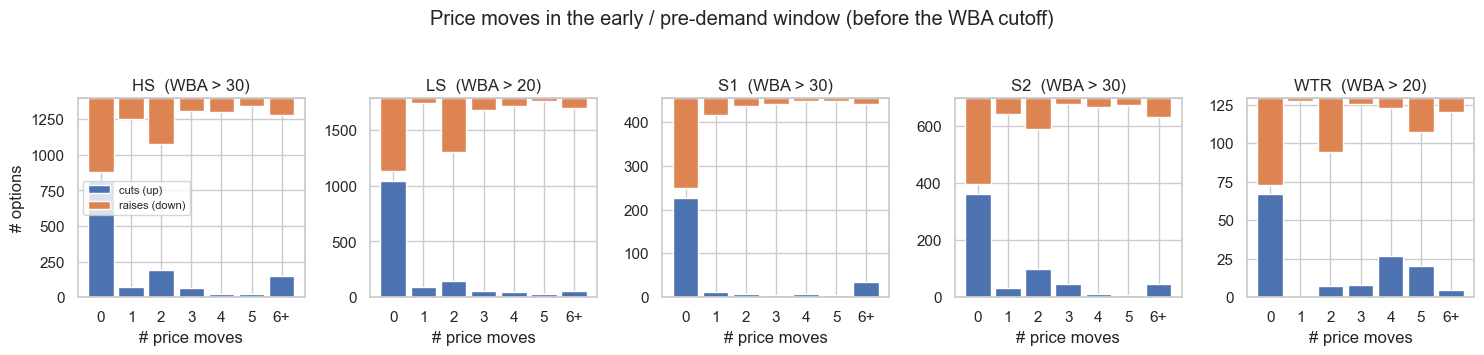

interactive(children=(IntSlider(value=0, description='WBA cutoff', max=50, step=5), Output()), _dom_classes=('…

<function __main__.show_wba(global_wba)>

In [8]:
# --- WBA trigger: moves in the EARLY / pre-demand window (WeekBeforeArrival > cutoff) ---
# Mean occupancy only lifts off ~WBA 30 (HS/S2), ~25 (S1), ~20 (LS); WTR fills late/weakly.
# Cutoffs are editable; the slider applies one global cutoff to every season.
WBA_CUTOFFS = {"HS": 30, "S1": 30, "S2": 30, "LS": 20, "WTR": 20}

def show_wba(global_wba):
    cut = WBA_CUTOFFS if global_wba == 0 else {s: global_wba for s in WBA_CUTOFFS}
    lab = {s: f"(WBA > {cut[s]})" for s in cut}
    plot_cut_raise(move_counts("wba", cut), lab,
                   "Price moves in the early / pre-demand window (before the WBA cutoff)")

show_wba(0)   # static default render
widgets.interact(show_wba, global_wba=widgets.IntSlider(
    value=0, min=0, max=50, step=5, description="WBA cutoff"))

## 4. The accommodation-range price ladder

Does the `Budget → Ultimate` range behave like a price ladder?

> ➡ **Decision:** the ordered `AccommodationRange` is encoded as a single numeric `RangeOrdinal` feature (the anonymised `CampsiteCluster` quality tier is absent from the final dataset, so `AccommodationRange` is the ordinal we have). The boxplots show whether the ladder is truly monotonic — it is only roughly so, which is why the one-hot `RangeType` is kept alongside the ordinal.

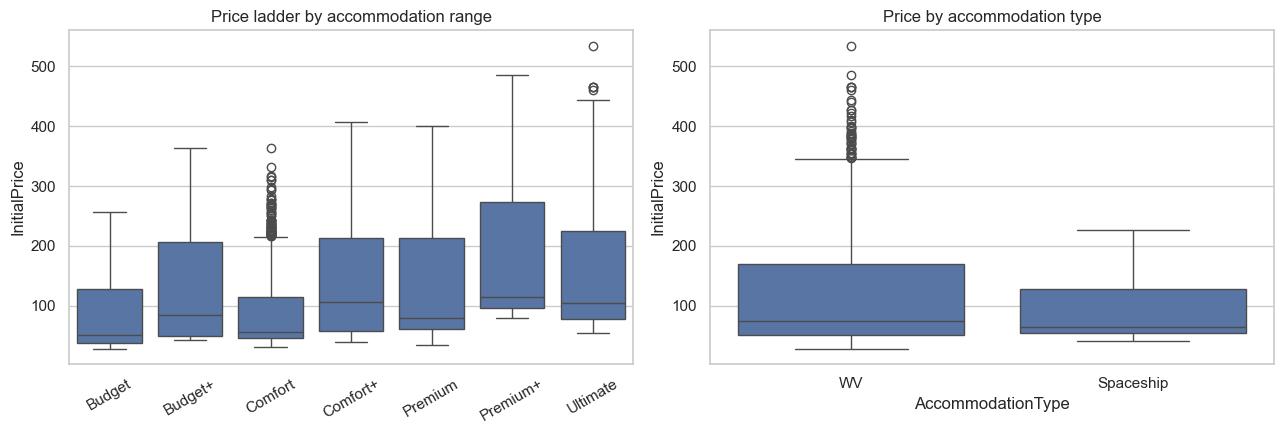

In [9]:
RANGE = ["Budget", "Budget+", "Comfort", "Comfort+", "Premium", "Premium+", "Ultimate"]
present = [r for r in RANGE if r in option_week["AccommodationRange"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=option_week, x="AccommodationRange", y="InitialPrice", order=present, ax=axes[0])
axes[0].set(title="Price ladder by accommodation range", xlabel="")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=option_week, x="AccommodationType", y="InitialPrice", ax=axes[1])
axes[1].set(title="Price by accommodation type")
fig.tight_layout()

## 5. This year vs last year

Where a prior-year price exists, how sticky is pricing year-on-year? This bounds how much the last-year feature can really do.

> ➡ **Decision:** the last-year price is a genuine signal **but only ~40% of options carry one**, so the pipeline adds a `has_last_year` flag and imputes the rest within a `SeasonalCluster × RangeType` segment — rather than trusting a single global median.

Last-year price available for 44% of options; corr where present = 0.90


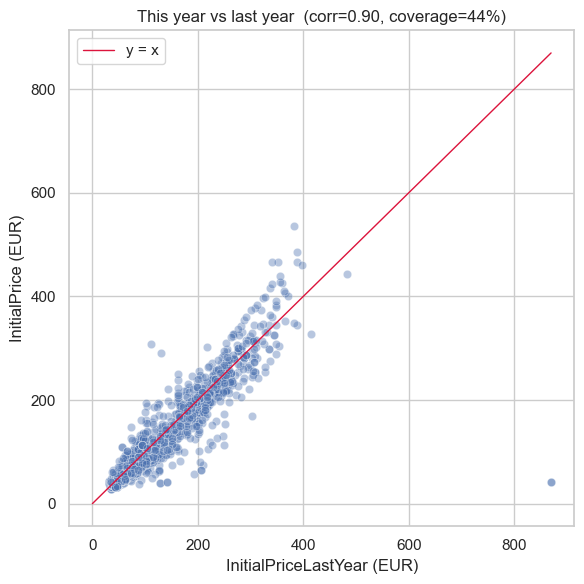

In [10]:
m = option_week.dropna(subset=["InitialPrice", "InitialPriceLastYear"])
cov = option_week["InitialPriceLastYear"].notna().mean()
corr = m["InitialPrice"].corr(m["InitialPriceLastYear"])

plt.figure(figsize=(6, 6))
sns.scatterplot(data=m, x="InitialPriceLastYear", y="InitialPrice", alpha=0.4)
lim = [0, max(m["InitialPrice"].max(), m["InitialPriceLastYear"].max())]
plt.plot(lim, lim, color="crimson", lw=1, label="y = x")
plt.title(f"This year vs last year  (corr={corr:.2f}, coverage={cov:.0%})")
plt.xlabel("InitialPriceLastYear (EUR)"); plt.ylabel("InitialPrice (EUR)")
plt.legend(); plt.tight_layout()
print(f"Last-year price available for {cov:.0%} of options; corr where present = {corr:.2f}")

## 6. Campsite price ranking

Which campsites are premium and which are budget? This gives a face to the many `CampsiteCode_*` dummies in the model.

> ➡ **Decision:** campsites with fewer than 30 options (red) are pooled into `"Other"` during training (learned on the train split only) to keep the one-hot width sane on a small sample.

campsites: 37 | pooled (<30 options): 14


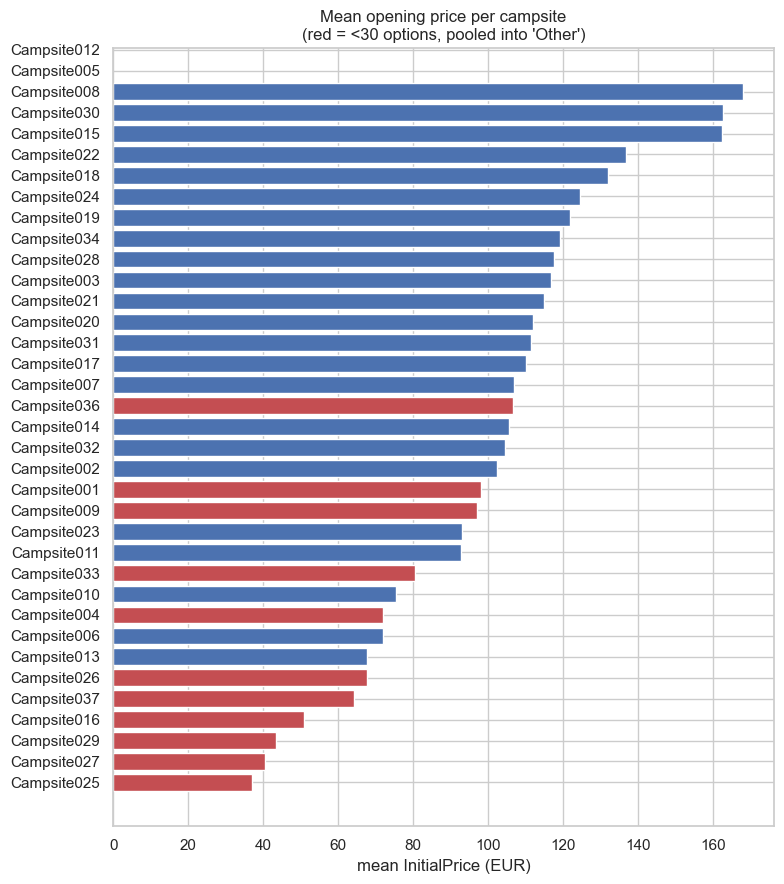

In [11]:
ranking = (option_week.groupby("CampsiteCode")
           .agg(mean_price=("InitialPrice", "mean"), n=("ReservableOptionId", "nunique"))
           .sort_values("mean_price"))
colors = np.where(ranking["n"] < 30, "#c44e52", "#4c72b0")

plt.figure(figsize=(8, 9))
plt.barh(ranking.index, ranking["mean_price"], color=colors)
plt.title("Mean opening price per campsite\n(red = <30 options, pooled into 'Other')")
plt.xlabel("mean InitialPrice (EUR)"); plt.tight_layout()
print(f"campsites: {len(ranking)} | pooled (<30 options): {(ranking['n'] < 30).sum()}")

## 7. Inter-campsite price variability (same product)

Do different campsites charge different opening prices for the **same** `AccoTypeRangeCode` (same product), within the same season? Each campsite's mean `InitialPrice` for a product is compared to a **campsite-weighted, leave-one-out peer baseline** — the average of the *other* campsites' means for that same product, season and year (every campsite counts once; the campsite itself is excluded). Accommodation mix and timing are thus held constant, leaving the **pure campsite effect**.

> ➡ **Decision:** yes — for an identical product, campsites differ by ~18% on average (some ~2× their peers), so `CampsiteCode` is a genuine price driver and is kept as a model feature. Timing (season) still dominates the *absolute* price; campsite is the main *residual* once product and season are fixed.

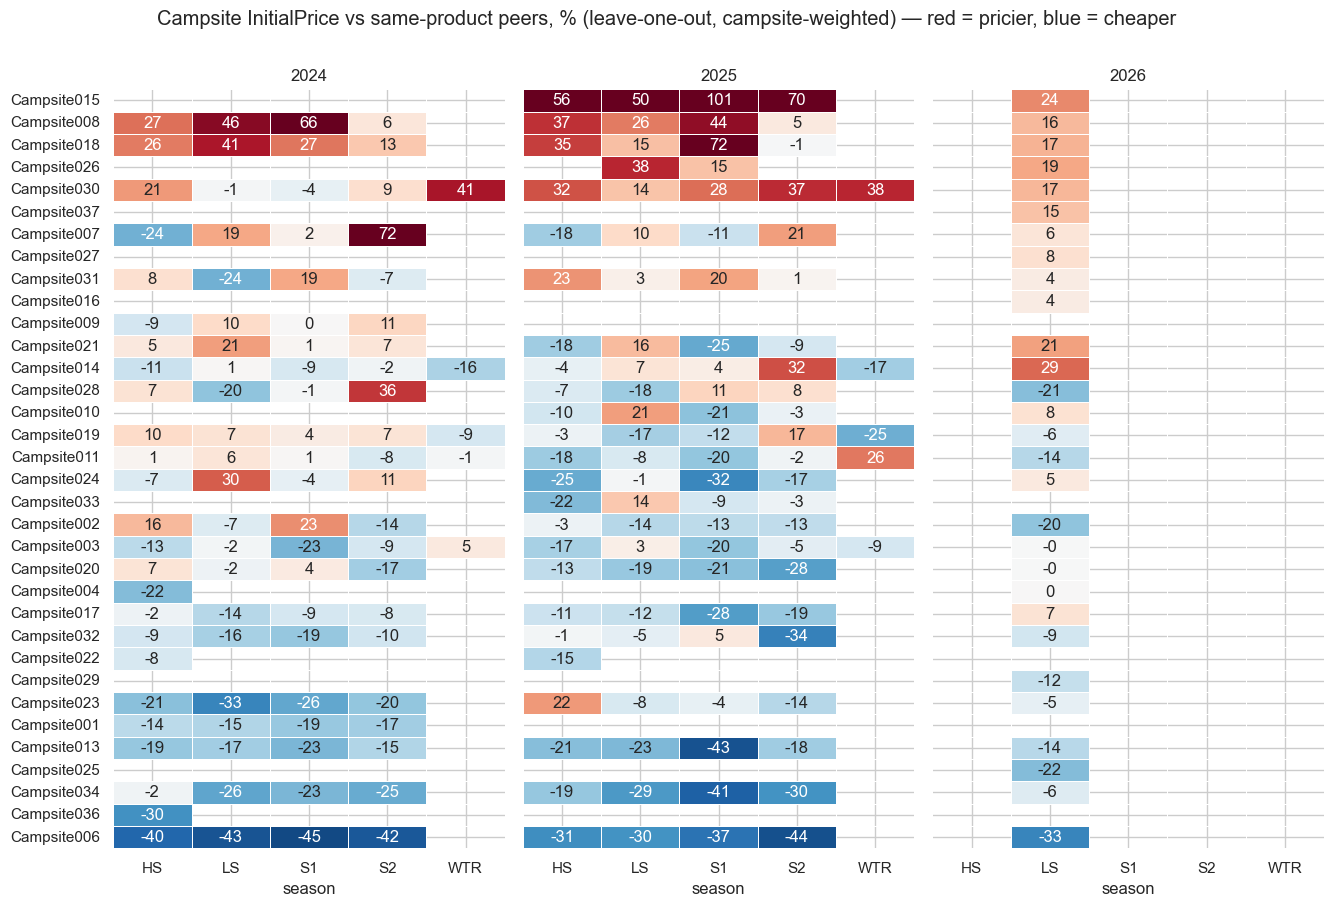

In [12]:
# Inter-campsite variability for the SAME product, using a CAMPSITE-WEIGHTED,
# LEAVE-ONE-OUT peer baseline (every campsite counts once; exclude the campsite itself).
ic = option_week[option_week["InitialPrice"] > 0][
    ["CampsiteCode", "SeasonalCluster", "AccoTypeRangeCode", "Year", "InitialPrice"]].copy()
grp = ["Year", "SeasonalCluster", "AccoTypeRangeCode"]

# 1) campsite-level mean price per product-season-year cell (campsite-weighted)
camp = ic.groupby(grp + ["CampsiteCode"])["InitialPrice"].mean().rename("camp_mean").reset_index()

# 2) leave-one-out peer mean within each product-season-year group (>= 3 campsites)
g = camp.groupby(grp)["camp_mean"]
camp["grp_sum"] = g.transform("sum")
camp["grp_n"] = g.transform("size")
camp = camp[camp["grp_n"] >= 3].copy()
camp["peer_mean"] = (camp["grp_sum"] - camp["camp_mean"]) / (camp["grp_n"] - 1)
camp["rel_pct"] = (camp["camp_mean"] / camp["peer_mean"] - 1) * 100

# 3) heatmap value: a campsite's mean deviation across its products, per (year, season)
cell = camp.groupby(["Year", "CampsiteCode", "SeasonalCluster"])["rel_pct"].mean().reset_index()
years = sorted(cell["Year"].unique())
seasons = ["HS", "LS", "S1", "S2", "WTR"]
order = cell.groupby("CampsiteCode")["rel_pct"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(1, len(years), figsize=(4.5 * len(years), 9), sharey=True)
for ax, y in zip(np.atleast_1d(axes), years):
    mat = (cell[cell["Year"] == y]
           .pivot(index="CampsiteCode", columns="SeasonalCluster", values="rel_pct")
           .reindex(index=order, columns=seasons))
    sns.heatmap(mat, ax=ax, cmap="RdBu_r", center=0, vmin=-50, vmax=50,
                annot=True, fmt=".0f", cbar=False, linewidths=0.4)
    ax.set_title(str(y)); ax.set_xlabel("season"); ax.set_ylabel("")
fig.suptitle("Campsite InitialPrice vs same-product peers, % (leave-one-out, campsite-weighted) "
             "— red = pricier, blue = cheaper", y=1.005)
fig.tight_layout()

Same-product campsite spread is real: median inter-campsite CV ~0.18-0.24;
e.g. 'WV | Chill+' in HS 2025 ranges roughly EUR 170-354 across 14 campsites.


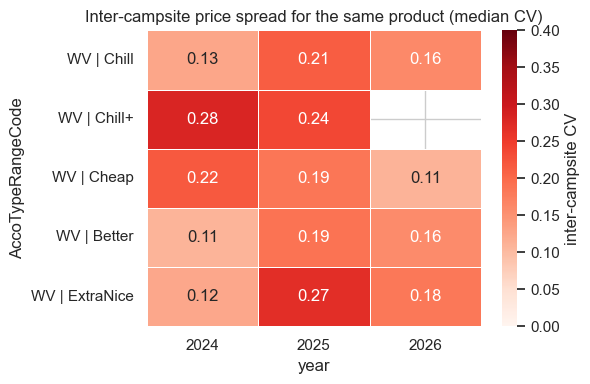

In [13]:
# How much do campsites disagree on the SAME product? (inter-campsite CV)
def _cv(g):
    cm = g.groupby("CampsiteCode")["InitialPrice"].mean()
    return cm.std() / cm.mean() if len(cm) >= 3 and cm.mean() > 0 else np.nan

prod_cv = (ic.groupby(["Year", "AccoTypeRangeCode", "SeasonalCluster"])
           .apply(_cv, include_groups=False).dropna().reset_index(name="cv"))
prod_mat = (prod_cv.groupby(["AccoTypeRangeCode", "Year"])["cv"].median()
            .reset_index().pivot(index="AccoTypeRangeCode", columns="Year", values="cv"))
prod_mat = prod_mat.reindex(ic["AccoTypeRangeCode"].value_counts().index).dropna(how="all")

plt.figure(figsize=(6, 4))
sns.heatmap(prod_mat, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=0.4,
            linewidths=0.4, cbar_kws={"label": "inter-campsite CV"})
plt.title("Inter-campsite price spread for the same product (median CV)")
plt.xlabel("year"); plt.ylabel("AccoTypeRangeCode"); plt.tight_layout()

print("Same-product campsite spread is real: median inter-campsite CV ~0.18-0.24;")
print("e.g. 'WV | Chill+' in HS 2025 ranges roughly EUR 170-354 across 14 campsites.")

## 8. Demand vs price & sell-out timing

Do options that end up fuller carry higher opening prices, and how early do they sell out?

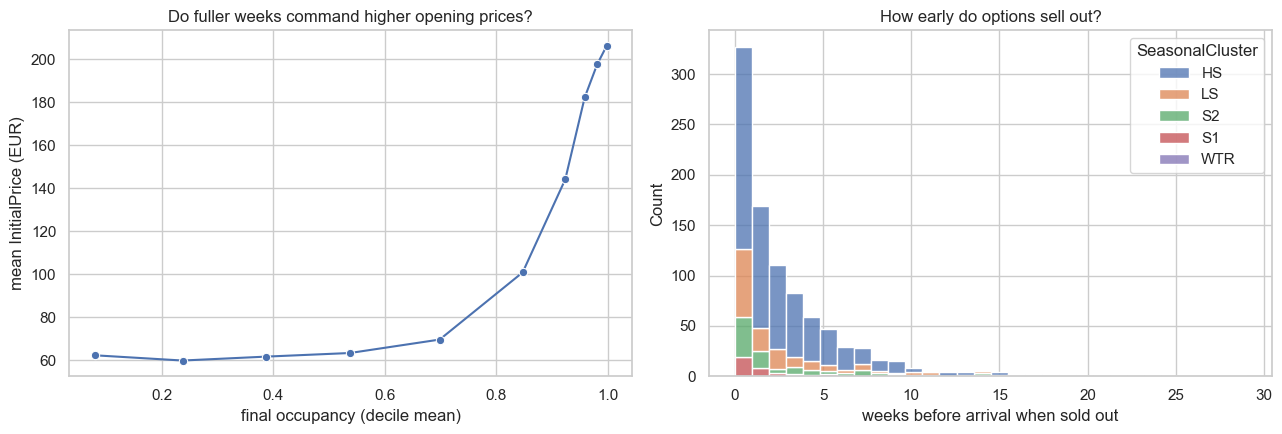

In [14]:
# Final occupancy per option (cumulative bookings at arrival, WBA == 0) vs opening price.
final_occ = curve.loc[curve["WeekBeforeArrival"] == 0, ["ReservableOptionId", "occupancy"]]
dp = (option_week.merge(final_occ, on="ReservableOptionId", how="inner")
      .dropna(subset=["InitialPrice", "occupancy"]))
dp["occ_decile"] = pd.qcut(dp["occupancy"], 10, labels=False, duplicates="drop")
band = dp.groupby("occ_decile").agg(occupancy=("occupancy", "mean"),
                                    price=("InitialPrice", "mean")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=band, x="occupancy", y="price", marker="o", ax=axes[0])
axes[0].set(title="Do fuller weeks command higher opening prices?",
           xlabel="final occupancy (decile mean)", ylabel="mean InitialPrice (EUR)")
sold = df.drop_duplicates("ReservableOptionId")
sns.histplot(data=sold, x="SoldOutWeekBeforeArrival", hue="SeasonalCluster",
             multiple="stack", bins=30, ax=axes[1])
axes[1].set(title="How early do options sell out?",
           xlabel="weeks before arrival when sold out")
fig.tight_layout()

## 9. Numeric correlations

A quick multicollinearity / driver view across the numeric features.

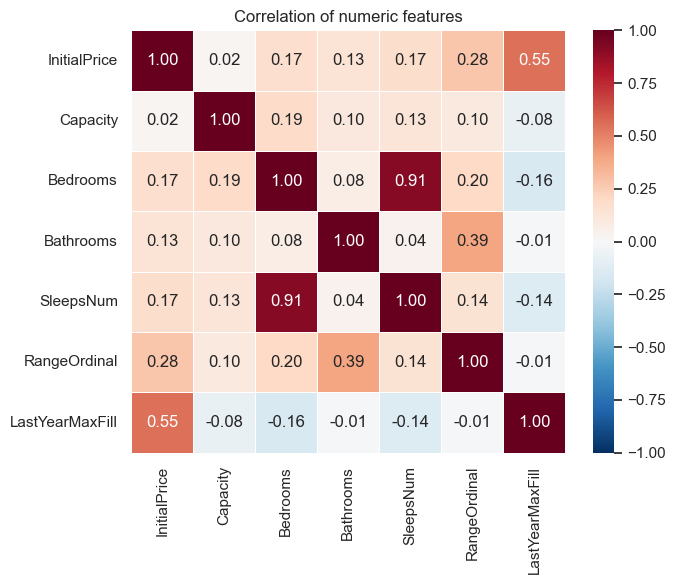

In [15]:
num = ["InitialPrice", "Capacity", "Bedrooms", "Bathrooms", "SleepsNum",
       "RangeOrdinal", "LastYearMaxFill"]
num = [c for c in num if c in option_week.columns]

plt.figure(figsize=(7, 6))
sns.heatmap(option_week[num].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation of numeric features"); plt.tight_layout()

# Part 2 — Methodology & Data Quality

The checks that establish the data is trustworthy. Each subsection ends with a `➡ Decision` callout pointing at the modelling choice it justifies.

## 2.1 Grain validation

`ReservableOptionId` should map one-to-one onto an arrival week.

> ➡ **Decision:** confirmed → the feature table is built at the **option-week grain** (`PriceFeatureBuilder.build_option_week_table`), one row per option.

In [16]:
# ReservableOptionId is a unique combo of accommodation type and arrival week.
unique_option_id = df["ReservableOptionId"].nunique()
unique_tuples = df[["ReservableOptionId", "WeekStartDate"]].drop_duplicates().shape[0]

print(f"unique ReservableOptionId            : {unique_option_id:,}")
print(f"unique (ReservableOptionId, WeekStart): {unique_tuples:,}")

if unique_option_id == unique_tuples:
    print("=> one option = one arrival week")

unique ReservableOptionId            : 3,842
unique (ReservableOptionId, WeekStart): 3,842
=> one option = one arrival week


## 2.2 Market-group structure

Each option carries 4 market groups, each with its own bookings.

> ➡ **Decision:** the 4 market rows are collapsed to one option-horizon record (`collapse_market_rows`: booked nights summed, price averaged) before any price is derived.

In [17]:
# How many market groups does each option carry?
market_groups_per_option = df.groupby("ReservableOptionId")["MarketGroupCode"].nunique()
print(market_groups_per_option.value_counts())
print("\nmarket group codes:", sorted(df["MarketGroupCode"].unique()))

MarketGroupCode
4    3842
Name: count, dtype: int64

market group codes: ['CN', 'IR', 'NK', 'US']


In [18]:
# Aggregate the 4 market groups up to one option-week record.
df["OptionCumulativeBookedNights"] = (
    df.groupby("ReservableOptionId")["CumulativeHistoricalBookedNights"].transform("sum")
)

market_rollup = df.drop_duplicates(["ReservableOptionId", "WeekBeforeArrival"]).copy()
market_rollup["BookingsPercentage"] = (
    market_rollup["OptionCumulativeBookedNights"] / market_rollup["Capacity"]
)

print(f"raw rows          : {len(df):,}")
print(f"option-week rows  : {len(market_rollup):,}")

raw rows          : 1,214,072
option-week rows  : 303,518


## 2.3 Data quality: monotonicity, overbooking, missingness

> ➡ **Decision:** cumulative bookings never decrease and overbooking is negligible, so `CumulativeHistoricalBookedNights / Capacity` is trusted as the **occupancy numerator** behind the X%-occupancy `TargetPrice`.

In [19]:
# CumulativeHistoricalBookedNights should never drop as the horizon shrinks (far -> near).
keys = ["ReservableOptionId", "MarketGroupCode", "WeekStartDate"]

ordered = df.sort_values(keys + ["WeekBeforeArrival"], ascending=[True, True, True, False])
ordered["booking_diff"] = ordered.groupby(keys)["CumulativeHistoricalBookedNights"].diff()

violations = ordered.loc[ordered["booking_diff"] < 0, keys].drop_duplicates()
print(f"series with a decrease in CumulativeHistoricalBookedNights: {len(violations)}")

series with a decrease in CumulativeHistoricalBookedNights: 0


In [20]:
# Overbooking: rows where bookings exceed capacity.
overbooked = df[df["TotalBookedNights"] > df["Capacity"]].copy()
overbooked["OverbookedPct"] = (
    (overbooked["TotalBookedNights"] - overbooked["Capacity"]) / overbooked["Capacity"] * 100
)

print(f"overbooked rows: {len(overbooked):,} ({len(overbooked) / len(df):.2%} of all rows)")
overbooked.groupby("ReservableOptionId")["OverbookedPct"].max().sort_values(ascending=False).head()

overbooked rows: 948 (0.08% of all rows)


ReservableOptionId
82155090    23.853211
82155031    21.338156
82155034     5.786618
82155027     2.486679
82155028     2.040816
Name: OverbookedPct, dtype: float64

**Missingness at a glance** — columns with any nulls (a quick visual replacement for per-column prints).

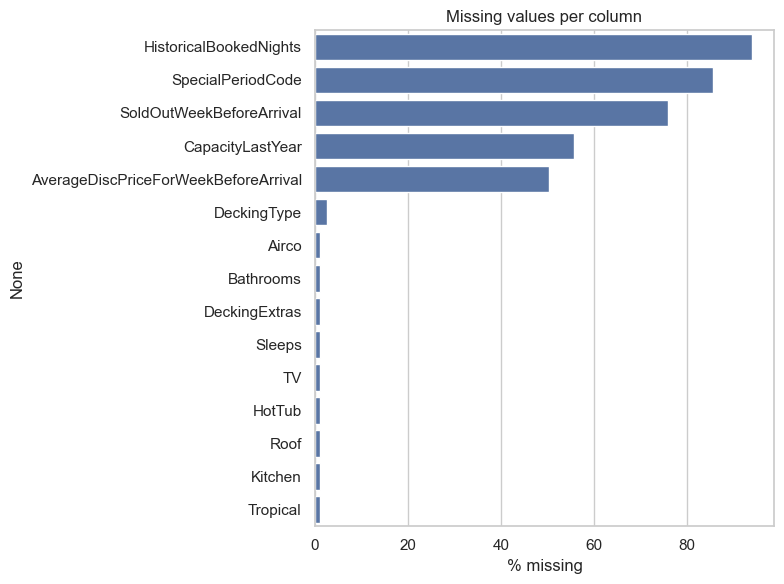

In [21]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(8, max(2, 0.4 * len(miss))))
sns.barplot(x=miss.values * 100, y=miss.index, color="#4c72b0")
plt.xlabel("% missing"); plt.title("Missing values per column"); plt.tight_layout()

## 2.4 Prior-year completeness & placeholder

How real is the last-year data, per arrival year?

> ➡ **Decision:** 2024 arrivals carry an **all-zero placeholder** last-year price, so a genuine prior-year price exists only for **2025→2026**. This forces approach 2's **LS-only proof-of-concept** window, and motivates the `has_last_year` flag, the segment-wise imputation, and the single-season warning the pipeline prints.

In [22]:
# Prior-year columns: how complete are they per season year?
ly = [
    "CumulativeHistoricalBookedNightsLastYear",
    "AverageDiscPriceForWeekBeforeArrivalLastYear",
    "CapacityLastYear",
]
df[ly].notna().groupby(df["Year"]).mean()

,CumulativeHistoricalBookedNightsLastYear,AverageDiscPriceForWeekBeforeArrivalLastYear,CapacityLastYear
Year,,,
2024,1.0,1.0,0.000000
2025,1.0,1.0,0.702786
2026,1.0,1.0,0.814921


In [23]:
# Placeholder vs real: a constant / all-zero spread signals a fake fill,
# a genuine spread signals real prior-year booking data.
df.loc[df["Year"] == 2024, "AverageDiscPriceForWeekBeforeArrivalLastYear"].describe()

count    483480.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: AverageDiscPriceForWeekBeforeArrivalLastYear, dtype: float64

**Imputation cell sizes — `SeasonalCluster × RangeType × CampsiteCode`.** The last-year imputation is campsite-aware (EDA §7), fit on the approach-2 train window (LS spring 2025). The cells are thin — most hold ~2 real last-year values — so the **minimum usable cell size is 1**: trust the campsite median whenever a cell has ≥1 real value, falling back to `Season × Range` otherwise. A threshold ≥3 would push most cells to the coarser group and *lower* held-out accuracy (imitator RF R² 0.50 → 0.40 at k=3, tested k=1…10).

In [24]:
# Cell sizes at the last-year imputation grain, in the approach-2 TRAIN window (LS 2025).
_wk = pd.to_datetime(option_week["WeekStartDate"])
train_win = option_week[(_wk >= "2025-01-01") & (_wk < "2025-06-08")]
ly = "InitialPriceLastYear"

def _grain_row(seg, name):
    real = train_win.groupby(seg)[ly].apply(lambda s: s.notna().sum())
    rows = train_win.groupby(seg).size()
    return {"grain": name, "cells": len(real),
            "median rows/cell": int(rows.median()),
            "cells w/ >=1 real LY": int((real >= 1).sum()),
            "median real LY/cell": int(real.median())}

summary = pd.DataFrame([
    _grain_row(["SeasonalCluster", "RangeType"], "Season x Range"),
    _grain_row(["SeasonalCluster", "RangeType", "CampsiteCode"], "Season x Range x Campsite"),
])
print("Imputation grain comparison (LS-2025 train window):")
display(summary)

real = train_win.groupby(["SeasonalCluster", "RangeType", "CampsiteCode"])[ly].apply(
    lambda s: s.notna().sum())
dist = (pd.cut(real, [-1, 0, 1, 2, 4, 1e9], labels=["0", "1", "2", "3-4", "5+"])
        .value_counts().reindex(["0", "1", "2", "3-4", "5+"]).rename("cells").to_frame())
print(f"\nSeason x Range x Campsite cells by # real last-year values "
      f"({train_win[ly].isna().sum()} of {len(train_win)} train rows need imputation):")
display(dist)

Imputation grain comparison (LS-2025 train window):


,grain,cells,median rows/cell,cells w/ >=1 real LY,median real LY/cell
0,Season x Range,7,60,7,12
1,Season x Range x Campsite,47,10,44,2



Season x Range x Campsite cells by # real last-year values (426 of 543 train rows need imputation):


,cells
InitialPriceLastYear,
0,3
1,2
2,31
3-4,8
5+,3


## 2.5 Feature diagnostics: cardinality & redundancy

> ➡ **Decision:** `CampsiteCode` is high-cardinality → rare levels are pooled into `"Other"` (train-frequency). `Airco`/`TV`/`DeckingType`/`Bathrooms` vary *within* a range code (not redundant), so they are kept and **train-mode**-filled.

In [25]:
# Categorical cardinality — high-cardinality fields are one-hot-width risks.
for column in df.select_dtypes("object").columns:
    n = df[column].nunique()
    print(f"{column}: {n} unique")
    if n <= 12:
        print("   ", sorted(df[column].dropna().unique()))

BrandGroupCode: 2 unique
    ['BrandGroup1', 'BrandGroup2']
CampsiteCode: 37 unique
AccoTypeRangeCode: 8 unique


    ['Spaceship | Chill', 'WV | Better', 'WV | Better+', 'WV | Cheap', 'WV | Cheap+', 'WV | Chill', 'WV | Chill+', 'WV | ExtraNice']
MarketGroupCode: 4 unique
    ['CN', 'IR', 'NK', 'US']
SeasonalCluster: 5 unique


    ['HS', 'LS', 'S1', 'S2', 'WTR']
CampsiteCountry: 1 unique
    ['Vietnam']
CampsiteRegion: 2 unique


    ['Mi Hauw', 'Phuh Cock']
CampsiteType: 2 unique
    ['Own', 'Partner']
AccommodationType: 2 unique


    ['Chalet', 'MH']
AccommodationRange: 7 unique
    ['Budget', 'Budget+', 'Comfort', 'Comfort+', 'Premium', 'Premium+', 'Ultimate']
Airco: 2 unique


    [False, True]
Bedrooms: 2 unique
    ['2 Bed', '3 Bed']
DeckingType: 4 unique


    ['Covered Decking', 'Decking', 'Lounge Decking', 'Small Decking']
HotTub: 1 unique
    [False]
Tropical: 1 unique
    [False]


Roof: 1 unique
    [False]
Kitchen: 1 unique
    [False]
DeckingExtras: 1 unique


    [False]
Sleeps: 8 unique
    ['4', '4-6', '4/6', '5', '6', '6-8', '6/8', '7']
TV: 2 unique
    [False, True]


In [26]:
# How many unique options does each campsite have? (37 campsites have >100 unique options.)

unique_counts = (
    df.groupby("CampsiteCode")["ReservableOptionId"]
    .nunique()
    .reset_index(name="UniqueReservableOptions")
)
unique_counts.sort_values("UniqueReservableOptions", ascending=False).head(37)

,CampsiteCode,UniqueReservableOptions
18,Campsite019,500
16,Campsite017,400
29,Campsite030,379
2,Campsite003,281
17,Campsite018,233
6,Campsite007,194
12,Campsite013,179
1,Campsite002,175
10,Campsite011,161
20,Campsite021,139


In [27]:
# Are these attributes fully determined by AccoTypeRangeCode?
redundancy_candidates = ["Airco", "TV", "DeckingType", "Bathrooms"]

determinism = (
    df.groupby("AccoTypeRangeCode")[redundancy_candidates]
    .nunique()
    .max()                       # worst case across all type|range groups
    .rename("max_unique_within_group")
)
print(determinism)
# max == 1  -> redundant: deterministic function of AccoTypeRangeCode
# max >= 2  -> keep: varies within a type|range, so it adds information

Airco          2
TV             2
DeckingType    3
Bathrooms      2
Name: max_unique_within_group, dtype: int64


## 2.6 Seasonal structure

Which seasonal clusters appear in each year, and how does demand shape differ?

> ➡ **Decision:** clusters map to different weeks/counts across years (a cross-year covariate shift), so results are reported **per `SeasonalCluster`** and the pipeline warns whenever the test window collapses to a single season.

In [28]:
# Which SeasonalClusters appear in each season year, and how many options back them?
season_pivot = (
    df.groupby(["SeasonalCluster", "Year"])
    .agg(
        MinDate=("WeekStartDate", "min"),
        MaxDate=("WeekStartDate", "max"),
        UniqueOptions=("ReservableOptionId", "nunique"),
    )
    .reset_index()
    .sort_values(["SeasonalCluster", "Year"])
)
print(season_pivot.to_string(index=False))

SeasonalCluster  Year    MinDate    MaxDate  UniqueOptions
             HS  2024 2024-07-06 2024-08-24            781
             HS  2025 2025-07-05 2025-08-23            556
             LS  2024 2024-06-08 2024-06-15            167
             LS  2025 2025-04-05 2025-06-14            606
             LS  2026 2026-03-28 2026-05-30            697
             S1  2024 2024-06-22 2024-06-29            172
             S1  2025 2025-06-21 2025-06-28            127
             S2  2024 2024-08-31 2024-09-28            330
             S2  2025 2025-08-30 2025-09-27            272
            WTR  2024 2024-10-05 2024-10-26             80
            WTR  2025 2025-10-04 2025-10-25             54


In [29]:
# Capacity-weighted booking fill per campsite across arrival weeks (at window open, WBA == 0).


at_start = df[df["WeekBeforeArrival"] == 0].copy()
at_start["OptionBookedNights"] = (
    at_start.groupby("ReservableOptionId")["CumulativeHistoricalBookedNights"].transform("sum")
)
at_start_option = at_start.drop_duplicates("ReservableOptionId")

campsite_weighted = at_start_option.groupby(["WeekStartDate", "CampsiteCode"]).agg(
    booked=("OptionBookedNights", "sum"),
    capacity=("Capacity", "sum"),
)
campsite_table_weighted = (campsite_weighted["booked"] / campsite_weighted["capacity"]).unstack()

campsite_dropdown = widgets.Dropdown(
    options=["All"] + list(campsite_table_weighted.columns),
    value="All",
    description="Campsite:",
)
plot_output = widgets.Output()


def _on_change(change):
    if change["name"] != "value" or change["new"] is None:
        return
    with plot_output:
        plot_output.clear_output(wait=True)
        selection = change["new"]
        data = (
            campsite_table_weighted
            if selection == "All"
            else campsite_table_weighted[[selection]]
        )
        ax = data.plot(figsize=(12, 6))
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        ax.set_ylabel("Capacity-weighted bookings %")
        plt.tight_layout()
        plt.show()


campsite_dropdown.observe(_on_change, names="value")
display(campsite_dropdown, plot_output)
_on_change({"name": "value", "new": campsite_dropdown.value})

Dropdown(description='Campsite:', options=('All', 'Campsite001', 'Campsite002', 'Campsite003', 'Campsite004', …

Output()